In [1]:
from pathlib import Path
import re
import pandas as pd

root = Path("/media/data/rPPG/rPPG_Data/SHARE/PixelLabelData")

img_dir = root / "FIR_input"
mask_dir = root / "PixelLabelData"

def natural_key(p):
    return [int(t) if t.isdigit() else t for t in re.split(r"(\d+)", p.name)]

imgs = sorted(img_dir.glob("*.bmp"), key=natural_key)
masks = sorted(mask_dir.glob("*.png"), key=natural_key)

print("Number of FIR images:", len(imgs))
print("Number of labels:", len(masks))

df = pd.DataFrame({
    "image_path": imgs[:min(len(imgs), len(masks))],
    "mask_path": masks[:min(len(imgs), len(masks))]
})

df["image_name"] = df["image_path"].apply(lambda x: x.name)
df["mask_name"] = df["mask_path"].apply(lambda x: x.name)

df.head(20)

Number of FIR images: 79
Number of labels: 79


,image_path,mask_path,image_name,mask_name
0,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-B-2.bmp,Label_1.png
1,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-B-3.bmp,Label_2.png
2,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-C-1.bmp,Label_3.png
3,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-C-2.bmp,Label_4.png
4,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-C-3.bmp,Label_5.png
5,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-D-1.bmp,Label_6.png
6,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-D-2.bmp,Label_7.png
7,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-D-3.bmp,Label_8.png
8,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S06-A-1.bmp,Label_9.png
9,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S06-A-2.bmp,Label_10.png


In [ ]:
df.to_csv(root / "manifest.csv", index=False)
print("Saved:", root / "manifest.csv")

Image shape: (256, 320) min: 0 max: 254
Mask shape: (256, 320) unique values: [0 1 2 3]


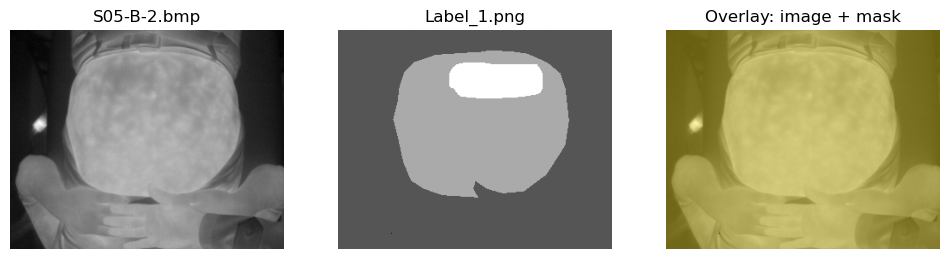

In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

idx = 0

img = np.array(Image.open(df.loc[idx, "image_path"]).convert("L"))
mask = np.array(Image.open(df.loc[idx, "mask_path"]))

print("Image shape:", img.shape, "min:", img.min(), "max:", img.max())
print("Mask shape:", mask.shape, "unique values:", np.unique(mask))

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title(df.loc[idx, "image_name"])
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title(df.loc[idx, "mask_name"])
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img, cmap="gray")
plt.imshow(mask > 0, alpha=0.4)
plt.title("Overlay: image + mask")
plt.axis("off")

plt.show()

In [3]:
from PIL import Image
import numpy as np

idx = 0
mask = np.array(Image.open(df.loc[idx, "mask_path"]).convert("L"))

print(np.unique(mask))
print("max value:", mask.max())

cold_mask = mask == mask.max()
print("cold pixels:", cold_mask.sum())

[0 1 2 3]
max value: 3
cold pixels: 4079


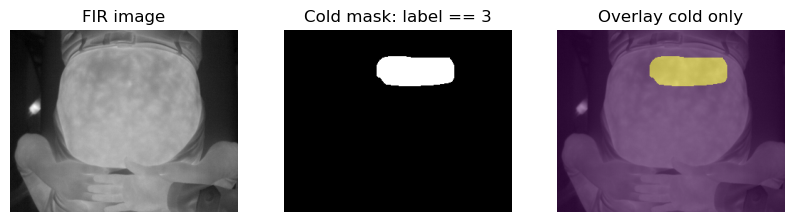

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

idx = 0

img = np.array(Image.open(df.loc[idx, "image_path"]).convert("L"))
mask = np.array(Image.open(df.loc[idx, "mask_path"]).convert("L"))

cold_mask = (mask == 3)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("FIR image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cold_mask, cmap="gray")
plt.title("Cold mask: label == 3")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img, cmap="gray")
plt.imshow(cold_mask, alpha=0.5)
plt.title("Overlay cold only")
plt.axis("off")

plt.show()

In [5]:
all_values = set()

for p in df["mask_path"]:
    mask = np.array(Image.open(p).convert("L"))
    all_values.update(np.unique(mask).tolist())

print("All label values:", sorted(all_values))

All label values: [0, 1, 2, 3]


# Step 1

In [6]:
from pathlib import Path
import re
import pandas as pd

root = Path("/media/data/rPPG/rPPG_Data/SHARE/PixelLabelData")

img_dir = root / "FIR_input"
mask_dir = root / "PixelLabelData"

def natural_key(p):
    return [int(t) if t.isdigit() else t for t in re.split(r"(\d+)", p.name)]

imgs = sorted(img_dir.glob("*.bmp"), key=natural_key)
masks = sorted(mask_dir.glob("*.png"), key=natural_key)

print("Number of FIR images:", len(imgs))
print("Number of labels:", len(masks))

assert len(imgs) == len(masks), "Image and label counts do not match!"

df = pd.DataFrame({
    "image_path": imgs,
    "mask_path": masks
})

df["image_name"] = df["image_path"].apply(lambda x: x.name)
df["mask_name"] = df["mask_path"].apply(lambda x: x.name)

df.head(10)

Number of FIR images: 79
Number of labels: 79


,image_path,mask_path,image_name,mask_name
0,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-B-2.bmp,Label_1.png
1,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-B-3.bmp,Label_2.png
2,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-C-1.bmp,Label_3.png
3,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-C-2.bmp,Label_4.png
4,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-C-3.bmp,Label_5.png
5,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-D-1.bmp,Label_6.png
6,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-D-2.bmp,Label_7.png
7,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-D-3.bmp,Label_8.png
8,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S06-A-1.bmp,Label_9.png
9,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S06-A-2.bmp,Label_10.png


# Step 2: Parse subject, doctor, and try number

In [7]:
def parse_image_name(name):
    # Example: S05-B-2.bmp
    m = re.match(r"(S\d+)-([A-D])-(\d+)\.bmp", name)
    if m is None:
        return None, None, None
    return m.group(1), m.group(2), int(m.group(3))

df[["subject", "doctor", "try"]] = df["image_name"].apply(
    lambda x: pd.Series(parse_image_name(x))
)

df.head(10)

,image_path,mask_path,image_name,mask_name,subject,doctor,try
0,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-B-2.bmp,Label_1.png,S05,B,2
1,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-B-3.bmp,Label_2.png,S05,B,3
2,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-C-1.bmp,Label_3.png,S05,C,1
3,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-C-2.bmp,Label_4.png,S05,C,2
4,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-C-3.bmp,Label_5.png,S05,C,3
5,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-D-1.bmp,Label_6.png,S05,D,1
6,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-D-2.bmp,Label_7.png,S05,D,2
7,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-D-3.bmp,Label_8.png,S05,D,3
8,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S06-A-1.bmp,Label_9.png,S06,A,1
9,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S06-A-2.bmp,Label_10.png,S06,A,2


# Step 3: Check the dataset distribution

In [8]:
print("Total samples:", len(df))
print("\nSubjects:")
print(df["subject"].value_counts().sort_index())

print("\nDoctors:")
print(df["doctor"].value_counts().sort_index())

print("\nTries:")
print(df["try"].value_counts().sort_index())

Total samples: 79

Subjects:
subject
S05     8
S06    11
S07    12
S08    12
S09    12
S10    12
S11    12
Name: count, dtype: int64

Doctors:
doctor
A    18
B    20
C    21
D    20
Name: count, dtype: int64

Tries:
try
1    26
2    26
3    27
Name: count, dtype: int64


# Step 4: Create train / validation / test split by subject

In [9]:
train_df = df[df["subject"].isin(["S05", "S06", "S07", "S08", "S09"])].reset_index(drop=True)
val_df   = df[df["subject"].isin(["S10"])].reset_index(drop=True)
test_df  = df[df["subject"].isin(["S11"])].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 55
Val: 12
Test: 12


# Step 5: Create the PyTorch Dataset

In [13]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class ColdRegionDataset(Dataset):
    def __init__(self, df, img_size=(320, 256)):  # PIL uses (W, H)
        self.df = df.reset_index(drop=True)
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        mask_path = self.df.loc[idx, "mask_path"]

        img = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        img = img.resize(self.img_size, resample=Image.BILINEAR)
        mask = mask.resize(self.img_size, resample=Image.NEAREST)

        img = np.array(img).astype(np.float32) / 255.0
        mask = np.array(mask).astype(np.uint8)

        cold_mask = (mask == 3).astype(np.float32)

        img = torch.tensor(img).unsqueeze(0)
        cold_mask = torch.tensor(cold_mask).unsqueeze(0)

        return img, cold_mask

In [14]:
train_ds = ColdRegionDataset(train_df)

x, y = train_ds[0]

print("Image shape:", x.shape)
print("Mask shape:", y.shape)
print("Image min/max:", x.min().item(), x.max().item())
print("Mask min/max:", y.min().item(), y.max().item())
print("Cold pixels:", y.sum().item())

Image shape: torch.Size([1, 256, 320])
Mask shape: torch.Size([1, 256, 320])
Image min/max: 0.0 0.9960784316062927
Mask min/max: 0.0 1.0
Cold pixels: 4079.0


# Step 6: Create DataLoaders

In [15]:
from torch.utils.data import DataLoader

train_ds = ColdRegionDataset(train_df)
val_ds   = ColdRegionDataset(val_df)
test_ds  = ColdRegionDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=4, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=4, shuffle=False)

xb, yb = next(iter(train_loader))

print("Batch image shape:", xb.shape)
print("Batch mask shape:", yb.shape)

Batch image shape: torch.Size([4, 1, 256, 320])
Batch mask shape: torch.Size([4, 1, 256, 320])


# Step 7: Visualize one batch from DataLoader

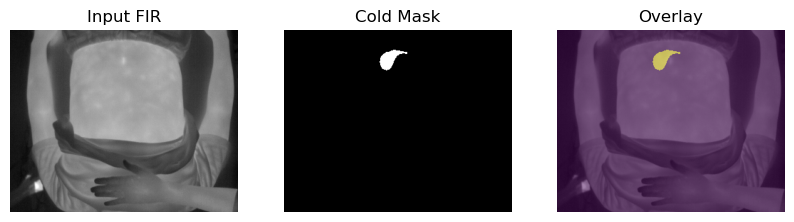

In [16]:
import matplotlib.pyplot as plt

xb, yb = next(iter(train_loader))

i = 0

img = xb[i, 0].numpy()
mask = yb[i, 0].numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Input FIR")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Cold Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(mask, alpha=0.5)
plt.title("Overlay")
plt.axis("off")

plt.show()

# Step 8: Define a very small U-Net model

In [17]:
import torch
import torch.nn as nn

class SmallUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)

        self.dec2 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)

        self.dec1 = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.out = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))

        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SmallUNet().to(device)

xb, yb = next(iter(train_loader))
xb = xb.to(device)

out = model(xb)

print("Input shape:", xb.shape)
print("Output shape:", out.shape)

/home/rafsan/miniconda3/envs/torch_on/lib/python3.11/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Input shape: torch.Size([4, 1, 256, 320])
Output shape: torch.Size([4, 1, 256, 320])


# Step 9: Define loss and Dice metric

In [19]:
import torch.nn.functional as F

def dice_score_from_logits(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))

    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean()

def bce_dice_loss(logits, targets, eps=1e-6):
    bce = F.binary_cross_entropy_with_logits(logits, targets)

    probs = torch.sigmoid(logits)
    intersection = (probs * targets).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))

    dice_loss = 1 - ((2 * intersection + eps) / (union + eps)).mean()

    return bce + dice_loss

In [20]:
xb, yb = next(iter(train_loader))
xb = xb.to(device)
yb = yb.to(device)

logits = model(xb)

loss = bce_dice_loss(logits, yb)
dice = dice_score_from_logits(logits, yb)

print("Loss:", loss.item())
print("Dice:", dice.item())

Loss: 1.705324411392212
Dice: 0.01880050078034401


In [21]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Optimizer ready")

Optimizer ready


# Step 11: Train for 1 epoch only

In [22]:
model.train()

total_loss = 0
total_dice = 0

for xb, yb in train_loader:
    xb = xb.to(device)
    yb = yb.to(device)

    optimizer.zero_grad()

    logits = model(xb)
    loss = bce_dice_loss(logits, yb)

    loss.backward()
    optimizer.step()

    dice = dice_score_from_logits(logits.detach(), yb)

    total_loss += loss.item()
    total_dice += dice.item()

avg_loss = total_loss / len(train_loader)
avg_dice = total_dice / len(train_loader)

print("Train loss:", avg_loss)
print("Train Dice:", avg_dice)

Train loss: 1.6563215851783752
Train Dice: 0.008549432169981417


# Step 12: Add validation loop

In [23]:
model.eval()

val_loss = 0
val_dice = 0

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = bce_dice_loss(logits, yb)
        dice = dice_score_from_logits(logits, yb)

        val_loss += loss.item()
        val_dice += dice.item()

avg_val_loss = val_loss / len(val_loader)
avg_val_dice = val_dice / len(val_loader)

print("Val loss:", avg_val_loss)
print("Val Dice:", avg_val_dice)

Val loss: 1.528692086537679
Val Dice: 8.527771896045996e-09


# Step 13: Train for 20 epochs

In [24]:
num_epochs = 20

for epoch in range(1, num_epochs + 1):
    model.train()
    train_loss = 0
    train_dice = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = bce_dice_loss(logits, yb)

        loss.backward()
        optimizer.step()

        dice = dice_score_from_logits(logits.detach(), yb)

        train_loss += loss.item()
        train_dice += dice.item()

    train_loss /= len(train_loader)
    train_dice /= len(train_loader)

    model.eval()
    val_loss = 0
    val_dice = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = bce_dice_loss(logits, yb)
            dice = dice_score_from_logits(logits, yb)

            val_loss += loss.item()
            val_dice += dice.item()

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}"
    )

Epoch 01 | Train Loss: 1.2017 | Train Dice: 0.0179 | Val Loss: 1.0399 | Val Dice: 0.0000
Epoch 02 | Train Loss: 1.0786 | Train Dice: 0.0179 | Val Loss: 1.0277 | Val Dice: 0.0000
Epoch 03 | Train Loss: 1.0766 | Train Dice: 0.0179 | Val Loss: 1.0190 | Val Dice: 0.0000
Epoch 04 | Train Loss: 1.0529 | Train Dice: 0.0179 | Val Loss: 1.0098 | Val Dice: 0.0000
Epoch 05 | Train Loss: 1.0217 | Train Dice: 0.0179 | Val Loss: 1.0016 | Val Dice: 0.0000
Epoch 06 | Train Loss: 1.0173 | Train Dice: 0.0179 | Val Loss: 1.0006 | Val Dice: 0.0000
Epoch 07 | Train Loss: 1.0128 | Train Dice: 0.0179 | Val Loss: 0.9980 | Val Dice: 0.0000
Epoch 08 | Train Loss: 1.0103 | Train Dice: 0.0179 | Val Loss: 1.0043 | Val Dice: 0.0000
Epoch 09 | Train Loss: 1.0121 | Train Dice: 0.0179 | Val Loss: 0.9917 | Val Dice: 0.0000
Epoch 10 | Train Loss: 1.0170 | Train Dice: 0.0179 | Val Loss: 1.0076 | Val Dice: 0.0000
Epoch 11 | Train Loss: 1.0275 | Train Dice: 0.0179 | Val Loss: 1.0189 | Val Dice: 0.0000
Epoch 12 | Train Loss

# Step 14: Check prediction values

In [25]:
model.eval()

xb, yb = next(iter(val_loader))
xb = xb.to(device)
yb = yb.to(device)

with torch.no_grad():
    logits = model(xb)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

print("GT cold pixels:", yb.sum().item())
print("Pred cold pixels:", preds.sum().item())

print("Prob min:", probs.min().item())
print("Prob max:", probs.max().item())
print("Prob mean:", probs.mean().item())

GT cold pixels: 293.0
Pred cold pixels: 0.0
Prob min: 2.6868449590027276e-25
Prob max: 0.320997953414917
Prob mean: 0.022296324372291565


# Step 15: Check Dice with lower thresholds

In [26]:
for th in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:
    preds = (probs > th).float()

    intersection = (preds * yb).sum()
    union = preds.sum() + yb.sum()
    dice = (2 * intersection + 1e-6) / (union + 1e-6)

    print(f"Threshold {th:.2f} | Pred pixels: {preds.sum().item():.0f} | Dice: {dice.item():.4f}")

Threshold 0.05 | Pred pixels: 38047 | Dice: 0.0152
Threshold 0.10 | Pred pixels: 33590 | Dice: 0.0171
Threshold 0.15 | Pred pixels: 30289 | Dice: 0.0188
Threshold 0.20 | Pred pixels: 24486 | Dice: 0.0208
Threshold 0.25 | Pred pixels: 1039 | Dice: 0.1471
Threshold 0.30 | Pred pixels: 300 | Dice: 0.1484


# Step 16: Visualize prediction using threshold 0.30

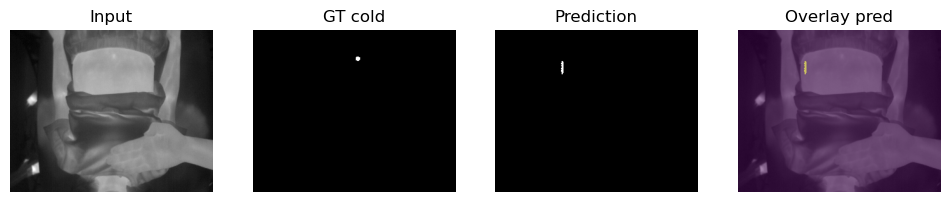

In [27]:
i = 0
th = 0.30

img = xb[i, 0].detach().cpu().numpy()
gt  = yb[i, 0].detach().cpu().numpy()
pr  = (probs[i, 0].detach().cpu().numpy() > th).astype(float)

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(gt, cmap="gray")
plt.title("GT cold")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(pr, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(img, cmap="gray")
plt.imshow(pr, alpha=0.5)
plt.title("Overlay pred")
plt.axis("off")

plt.show()

# Step 17: Check cold-region size statistics

In [28]:
cold_pixels = []

for i in range(len(train_ds)):
    x, y = train_ds[i]
    cold_pixels.append(y.sum().item())

cold_pixels = np.array(cold_pixels)

print("Train masks:", len(cold_pixels))
print("Min cold pixels:", cold_pixels.min())
print("Max cold pixels:", cold_pixels.max())
print("Mean cold pixels:", cold_pixels.mean())
print("Median cold pixels:", np.median(cold_pixels))
print("Empty masks:", np.sum(cold_pixels == 0))

Train masks: 55
Min cold pixels: 0.0
Max cold pixels: 9837.0
Mean cold pixels: 970.4
Median cold pixels: 500.0
Empty masks: 1


# Step 18: Use weighted BCE loss

In [30]:
def bce_dice_loss(logits, targets, eps=1e-6):
    pos_weight = torch.tensor([20.0], device=logits.device)

    bce = F.binary_cross_entropy_with_logits(
        logits, targets, pos_weight=pos_weight
    )

    probs = torch.sigmoid(logits)
    intersection = (probs * targets).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))

    dice_loss = 1 - ((2 * intersection + eps) / (union + eps)).mean()

    return bce + dice_loss

model = SmallUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Model reset with weighted loss")

Model reset with weighted loss


# Step 19: Train again with weighted loss

In [31]:
num_epochs = 20

for epoch in range(1, num_epochs + 1):
    model.train()
    train_loss = 0
    train_dice = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        logits = model(xb)
        loss = bce_dice_loss(logits, yb)

        loss.backward()
        optimizer.step()

        dice = dice_score_from_logits(logits.detach(), yb, threshold=0.30)

        train_loss += loss.item()
        train_dice += dice.item()

    train_loss /= len(train_loader)
    train_dice /= len(train_loader)

    model.eval()
    val_loss = 0
    val_dice = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = bce_dice_loss(logits, yb)
            dice = dice_score_from_logits(logits, yb, threshold=0.30)

            val_loss += loss.item()
            val_dice += dice.item()

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | Train Dice@0.30: {train_dice:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Dice@0.30: {val_dice:.4f}"
    )

Epoch 01 | Train Loss: 1.8556 | Train Dice@0.30: 0.0227 | Val Loss: 1.4621 | Val Dice@0.30: 0.0056
Epoch 02 | Train Loss: 1.7321 | Train Dice@0.30: 0.0082 | Val Loss: 1.4473 | Val Dice@0.30: 0.0096
Epoch 03 | Train Loss: 1.4917 | Train Dice@0.30: 0.0216 | Val Loss: 1.1539 | Val Dice@0.30: 0.0000
Epoch 04 | Train Loss: 1.4617 | Train Dice@0.30: 0.0348 | Val Loss: 1.2247 | Val Dice@0.30: 0.0241
Epoch 05 | Train Loss: 1.3510 | Train Dice@0.30: 0.0774 | Val Loss: 1.1458 | Val Dice@0.30: 0.0332
Epoch 06 | Train Loss: 1.3115 | Train Dice@0.30: 0.0897 | Val Loss: 1.1200 | Val Dice@0.30: 0.0412
Epoch 07 | Train Loss: 1.2898 | Train Dice@0.30: 0.0899 | Val Loss: 1.1438 | Val Dice@0.30: 0.0372
Epoch 08 | Train Loss: 1.3035 | Train Dice@0.30: 0.0919 | Val Loss: 1.1410 | Val Dice@0.30: 0.0385
Epoch 09 | Train Loss: 1.2945 | Train Dice@0.30: 0.0895 | Val Loss: 1.1309 | Val Dice@0.30: 0.0412
Epoch 10 | Train Loss: 1.2807 | Train Dice@0.30: 0.0922 | Val Loss: 1.1325 | Val Dice@0.30: 0.0415
Epoch 11 |

# Step 20: Train again and save best model

In [35]:
best_val_dice = -1
best_path = "best_cold_region_unet.pt"

num_epochs = 50

for epoch in range(1, num_epochs + 1):
    model.train()
    train_loss = 0
    train_dice = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = bce_dice_loss(logits, yb)

        loss.backward()
        optimizer.step()

        dice = dice_score_from_logits(logits.detach(), yb, threshold=0.30)

        train_loss += loss.item()
        train_dice += dice.item()

    train_loss /= len(train_loader)
    train_dice /= len(train_loader)

    model.eval()
    val_loss = 0
    val_dice = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = bce_dice_loss(logits, yb)
            dice = dice_score_from_logits(logits, yb, threshold=0.30)

            val_loss += loss.item()
            val_dice += dice.item()

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), best_path)
        save_msg = "saved"
    else:
        save_msg = ""

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | Train Dice@0.30: {train_dice:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Dice@0.30: {val_dice:.4f} "
        f"{save_msg}"
    )

print("Best Val Dice:", best_val_dice)
print("Saved model:", best_path)

Epoch 01 | Train Loss: 1.1626 | Train Dice@0.30: 0.1907 | Val Loss: 1.0709 | Val Dice@0.30: 0.1435 saved
Epoch 02 | Train Loss: 1.1589 | Train Dice@0.30: 0.1899 | Val Loss: 1.0709 | Val Dice@0.30: 0.1435 
Epoch 03 | Train Loss: 1.1615 | Train Dice@0.30: 0.1889 | Val Loss: 1.0709 | Val Dice@0.30: 0.1435 
Epoch 04 | Train Loss: 1.1612 | Train Dice@0.30: 0.1862 | Val Loss: 1.0709 | Val Dice@0.30: 0.1435 
Epoch 05 | Train Loss: 1.1586 | Train Dice@0.30: 0.1888 | Val Loss: 1.0709 | Val Dice@0.30: 0.1435 
Epoch 06 | Train Loss: 1.1607 | Train Dice@0.30: 0.1894 | Val Loss: 1.0709 | Val Dice@0.30: 0.1435 
Epoch 07 | Train Loss: 1.1614 | Train Dice@0.30: 0.1867 | Val Loss: 1.0709 | Val Dice@0.30: 0.1435 
Epoch 08 | Train Loss: 1.1603 | Train Dice@0.30: 0.1869 | Val Loss: 1.0709 | Val Dice@0.30: 0.1435 
Epoch 09 | Train Loss: 1.1592 | Train Dice@0.30: 0.1876 | Val Loss: 1.0709 | Val Dice@0.30: 0.1435 
Epoch 10 | Train Loss: 1.1600 | Train Dice@0.30: 0.1865 | Val Loss: 1.0709 | Val Dice@0.30: 0.1

# Step 21: Load best model and visualize validation prediction

/tmp/ipykernel_2878726/1883707639.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_cold_region_unet.pt", map_location=device))


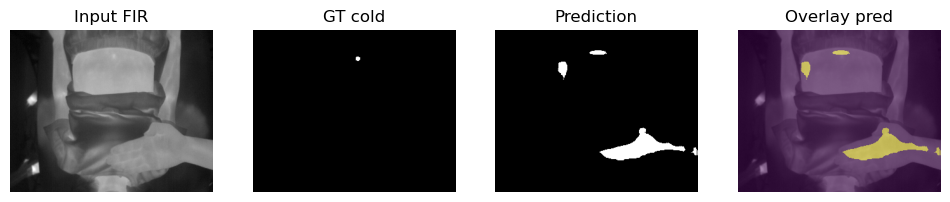

In [36]:
model = SmallUNet().to(device)
model.load_state_dict(torch.load("best_cold_region_unet.pt", map_location=device))
model.eval()

xb, yb = next(iter(val_loader))
xb = xb.to(device)
yb = yb.to(device)

with torch.no_grad():
    logits = model(xb)
    probs = torch.sigmoid(logits)

i = 0
th = 0.30

img = xb[i, 0].cpu().numpy()
gt = yb[i, 0].cpu().numpy()
pred = (probs[i, 0].cpu().numpy() > th).astype(float)

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Input FIR")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(gt, cmap="gray")
plt.title("GT cold")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(pred, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(img, cmap="gray")
plt.imshow(pred, alpha=0.5)
plt.title("Overlay pred")
plt.axis("off")

plt.show()

# Step 22: Update Dataset to return image, cold mask, and ROI mask

In [45]:
class ColdRegionDataset(Dataset):
    def __init__(self, df, img_size=(320, 256)):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        mask_path = self.df.loc[idx, "mask_path"]

        img = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        img = img.resize(self.img_size, resample=Image.BILINEAR)
        mask = mask.resize(self.img_size, resample=Image.NEAREST)

        img = np.array(img).astype(np.float32) / 255.0
        mask = np.array(mask).astype(np.uint8)

        cold_mask = (mask == 3).astype(np.float32)
        #roi_mask  = (mask > 0).astype(np.float32)
        roi_mask = (mask >= 2).astype(np.float32)

        img = torch.tensor(img).unsqueeze(0)
        cold_mask = torch.tensor(cold_mask).unsqueeze(0)
        roi_mask = torch.tensor(roi_mask).unsqueeze(0)

        return img, cold_mask, roi_mask
    

train_ds = ColdRegionDataset(train_df)
val_ds   = ColdRegionDataset(val_df)
test_ds  = ColdRegionDataset(test_df)

x, y, roi = train_ds[0]

print("Image:", x.shape)
print("Cold mask:", y.shape, y.sum().item())
print("ROI mask:", roi.shape, roi.sum().item())


Image: torch.Size([1, 256, 320])
Cold mask: torch.Size([1, 256, 320]) 4079.0
ROI mask: torch.Size([1, 256, 320]) 29231.0


# Step 23: Recreate DataLoaders for 3 outputs

In [46]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=4, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=4, shuffle=False)

xb, yb, rb = next(iter(train_loader))

print("Image batch:", xb.shape)
print("Cold mask batch:", yb.shape)
print("ROI mask batch:", rb.shape)

print("Cold pixels:", yb.sum().item())
print("ROI pixels:", rb.sum().item())

Image batch: torch.Size([4, 1, 256, 320])
Cold mask batch: torch.Size([4, 1, 256, 320])
ROI mask batch: torch.Size([4, 1, 256, 320])
Cold pixels: 2122.0
ROI pixels: 61046.0


# Step 24: Update loss and Dice to ignore outside abdomen

In [47]:
import torch.nn.functional as F

def masked_bce_dice_loss(logits, targets, roi_mask, eps=1e-6):
    pos_weight = torch.tensor([20.0], device=logits.device)

    bce_pixel = F.binary_cross_entropy_with_logits(
        logits, targets, pos_weight=pos_weight, reduction="none"
    )

    bce = (bce_pixel * roi_mask).sum() / (roi_mask.sum() + eps)

    probs = torch.sigmoid(logits)

    probs = probs * roi_mask
    targets = targets * roi_mask

    intersection = (probs * targets).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))

    dice_loss = 1 - ((2 * intersection + eps) / (union + eps)).mean()

    return bce + dice_loss


def masked_dice_score_from_logits(logits, targets, roi_mask, threshold=0.30, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds * roi_mask
    targets = targets * roi_mask

    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))

    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean()

# Step 25: Reset model and train with ROI-masked loss

In [48]:
model = SmallUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

best_val_dice = -1
best_path = "best_roi_masked_unet.pt"

num_epochs = 50

for epoch in range(1, num_epochs + 1):
    model.train()
    train_loss = 0
    train_dice = 0

    for xb, yb, rb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        rb = rb.to(device)

        optimizer.zero_grad()

        logits = model(xb)
        loss = masked_bce_dice_loss(logits, yb, rb)

        loss.backward()
        optimizer.step()

        dice = masked_dice_score_from_logits(logits.detach(), yb, rb, threshold=0.30)

        train_loss += loss.item()
        train_dice += dice.item()

    train_loss /= len(train_loader)
    train_dice /= len(train_loader)

    model.eval()
    val_loss = 0
    val_dice = 0

    with torch.no_grad():
        for xb, yb, rb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            rb = rb.to(device)

            logits = model(xb)
            loss = masked_bce_dice_loss(logits, yb, rb)
            dice = masked_dice_score_from_logits(logits, yb, rb, threshold=0.30)

            val_loss += loss.item()
            val_dice += dice.item()

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), best_path)
        save_msg = "saved"
    else:
        save_msg = ""

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | Train Dice@0.30: {train_dice:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Dice@0.30: {val_dice:.4f} "
        f"{save_msg}"
    )

print("Best Val Dice:", best_val_dice)
print("Saved model:", best_path)

Epoch 01 | Train Loss: 2.3434 | Train Dice@0.30: 0.1170 | Val Loss: 2.0546 | Val Dice@0.30: 0.0553 saved
Epoch 02 | Train Loss: 2.3394 | Train Dice@0.30: 0.1148 | Val Loss: 2.0562 | Val Dice@0.30: 0.0553 
Epoch 03 | Train Loss: 2.3134 | Train Dice@0.30: 0.1134 | Val Loss: 2.0577 | Val Dice@0.30: 0.0553 
Epoch 04 | Train Loss: 2.3303 | Train Dice@0.30: 0.1140 | Val Loss: 2.0570 | Val Dice@0.30: 0.0553 
Epoch 05 | Train Loss: 2.3570 | Train Dice@0.30: 0.1141 | Val Loss: 2.0563 | Val Dice@0.30: 0.0553 
Epoch 06 | Train Loss: 2.3081 | Train Dice@0.30: 0.1146 | Val Loss: 2.0579 | Val Dice@0.30: 0.0553 
Epoch 07 | Train Loss: 2.3620 | Train Dice@0.30: 0.1141 | Val Loss: 2.0582 | Val Dice@0.30: 0.0553 
Epoch 08 | Train Loss: 2.4006 | Train Dice@0.30: 0.1179 | Val Loss: 2.0563 | Val Dice@0.30: 0.0553 
Epoch 09 | Train Loss: 2.3220 | Train Dice@0.30: 0.1143 | Val Loss: 2.0609 | Val Dice@0.30: 0.0553 
Epoch 10 | Train Loss: 2.3313 | Train Dice@0.30: 0.1143 | Val Loss: 2.0606 | Val Dice@0.30: 0.0

# Step 26: Load previous best model and mask prediction by ROI

In [49]:
model = SmallUNet().to(device)
model.load_state_dict(torch.load("best_cold_region_unet.pt", map_location=device))
model.eval()

xb, yb, rb = next(iter(val_loader))
xb = xb.to(device)
yb = yb.to(device)
rb = rb.to(device)

with torch.no_grad():
    logits = model(xb)
    probs = torch.sigmoid(logits)

th = 0.30
pred = (probs > th).float()

# post-processing: remove predictions outside abdomen/body
pred_roi = pred * rb

print("GT cold pixels:", yb.sum().item())
print("Raw pred pixels:", pred.sum().item())
print("ROI-filtered pred pixels:", pred_roi.sum().item())

GT cold pixels: 293.0
Raw pred pixels: 14035.0
ROI-filtered pred pixels: 3736.0


/tmp/ipykernel_2878726/2736249478.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_cold_region_unet.pt", map_location=device))


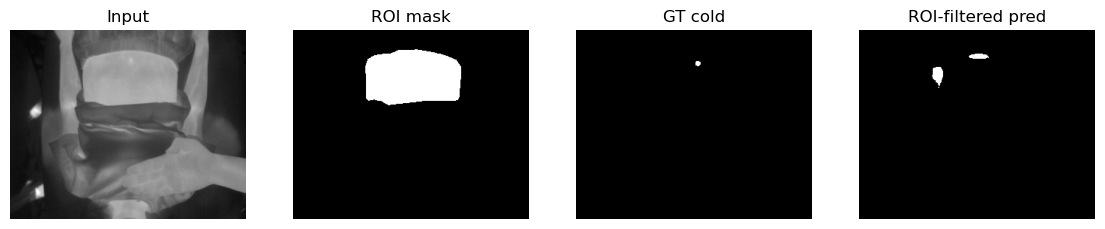

In [50]:
i = 0

img = xb[i, 0].detach().cpu().numpy()
gt  = yb[i, 0].detach().cpu().numpy()
roi = rb[i, 0].detach().cpu().numpy()
pred_roi_i = pred_roi[i, 0].detach().cpu().numpy()

plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(roi, cmap="gray")
plt.title("ROI mask")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(gt, cmap="gray")
plt.title("GT cold")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(pred_roi_i, cmap="gray")
plt.title("ROI-filtered pred")
plt.axis("off")

plt.show()

In [53]:
i = 0

print("GT pixels:", yb[i].sum().item())
print("ROI pixels:", rb[i].sum().item())
print("Raw pred pixels:", pred[i].sum().item())
print("ROI-filtered pred pixels:", pred_roi[i].sum().item())

print("Unique ROI values:", torch.unique(rb[i]))
print("Unique GT values:", torch.unique(yb[i]))
print("Unique pred_roi values:", torch.unique(pred_roi[i]))

GT pixels: 41.0
ROI pixels: 8358.0
Raw pred pixels: 3026.0
ROI-filtered pred pixels: 424.0
Unique ROI values: tensor([0., 1.], device='cuda:0')
Unique GT values: tensor([0., 1.], device='cuda:0')
Unique pred_roi values: tensor([0., 1.], device='cuda:0')


# Step 29: Check pixel counts of each label value

In [52]:
from PIL import Image
import numpy as np

idx = 0

mask_path = val_df.loc[idx, "mask_path"]
mask = np.array(Image.open(mask_path).convert("L"))

values, counts = np.unique(mask, return_counts=True)

print("Mask:", val_df.loc[idx, "mask_name"])
for v, c in zip(values, counts):
    print(f"Label {v}: {c} pixels")

Mask: Label_56.png
Label 1: 74706 pixels
Label 2: 8453 pixels
Label 3: 41 pixels


In [54]:
intersection = (pred_roi * yb).sum()
union = pred_roi.sum() + yb.sum()

dice_roi = (2 * intersection + 1e-6) / (union + 1e-6)

print("ROI-filtered Dice:", dice_roi.item())

ROI-filtered Dice: 0.05758252739906311


# Step 31: Try higher thresholds after ROI filtering

In [55]:
for th in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    pred = (probs > th).float()
    pred_roi = pred * rb

    intersection = (pred_roi * yb).sum()
    union = pred_roi.sum() + yb.sum()
    dice = (2 * intersection + 1e-6) / (union + 1e-6)

    print(
        f"Threshold {th:.2f} | "
        f"Pred pixels: {pred_roi.sum().item():.0f} | "
        f"Dice: {dice.item():.4f}"
    )

Threshold 0.30 | Pred pixels: 3736 | Dice: 0.0576
Threshold 0.40 | Pred pixels: 1971 | Dice: 0.0981
Threshold 0.50 | Pred pixels: 1459 | Dice: 0.1199
Threshold 0.60 | Pred pixels: 1162 | Dice: 0.1320
Threshold 0.70 | Pred pixels: 884 | Dice: 0.1444
Threshold 0.80 | Pred pixels: 506 | Dice: 0.1627


# Step 33: Visualize prediction with threshold 0.80

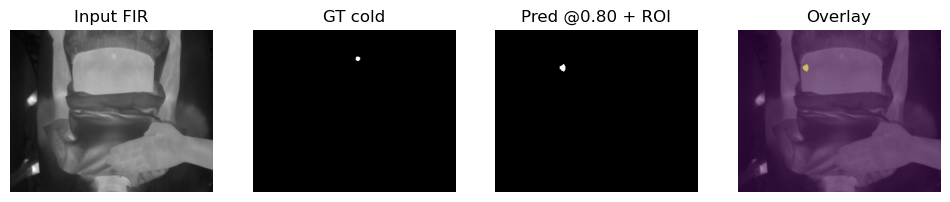

In [56]:
i = 0
th = 0.80

img = xb[i, 0].detach().cpu().numpy()
gt  = yb[i, 0].detach().cpu().numpy()
roi = rb[i, 0].detach().cpu().numpy()

pred = (probs[i, 0].detach().cpu().numpy() > th).astype(float)
pred_roi = pred * roi

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Input FIR")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(gt, cmap="gray")
plt.title("GT cold")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(pred_roi, cmap="gray")
plt.title("Pred @0.80 + ROI")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(img, cmap="gray")
plt.imshow(pred_roi, alpha=0.5)
plt.title("Overlay")
plt.axis("off")

plt.show()

In [57]:
for th in [0.80, 0.85, 0.90, 0.95]:
    pred = (probs > th).float()
    pred_roi = pred * rb

    intersection = (pred_roi * yb).sum()
    union = pred_roi.sum() + yb.sum()
    dice = (2 * intersection + 1e-6) / (union + 1e-6)

    print(
        f"Threshold {th:.2f} | "
        f"Pred pixels: {pred_roi.sum().item():.0f} | "
        f"Dice: {dice.item():.4f}"
    )

Threshold 0.80 | Pred pixels: 506 | Dice: 0.1627
Threshold 0.85 | Pred pixels: 312 | Dice: 0.1355
Threshold 0.90 | Pred pixels: 154 | Dice: 0.0805
Threshold 0.95 | Pred pixels: 27 | Dice: 0.0000


# Step 35: Evaluate threshold 0.80 on the full validation set

In [58]:
th = 0.80

model.eval()
val_dice = 0

with torch.no_grad():
    for xb, yb, rb in val_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        rb = rb.to(device)

        logits = model(xb)
        probs = torch.sigmoid(logits)

        pred = (probs > th).float()
        pred_roi = pred * rb

        intersection = (pred_roi * yb).sum(dim=(1, 2, 3))
        union = pred_roi.sum(dim=(1, 2, 3)) + yb.sum(dim=(1, 2, 3))

        dice = (2 * intersection + 1e-6) / (union + 1e-6)
        val_dice += dice.mean().item()

val_dice /= len(val_loader)

print("Validation Dice @0.80 + ROI:", val_dice)

Validation Dice @0.80 + ROI: 0.09880375613768895


# Step 36: Evaluate on test subject S11

In [59]:
th = 0.80

model.eval()
test_dice = 0

with torch.no_grad():
    for xb, yb, rb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        rb = rb.to(device)

        logits = model(xb)
        probs = torch.sigmoid(logits)

        pred = (probs > th).float()
        pred_roi = pred * rb

        intersection = (pred_roi * yb).sum(dim=(1, 2, 3))
        union = pred_roi.sum(dim=(1, 2, 3)) + yb.sum(dim=(1, 2, 3))

        dice = (2 * intersection + 1e-6) / (union + 1e-6)
        test_dice += dice.mean().item()

test_dice /= len(test_loader)

print("Test Dice @0.80 + ROI:", test_dice)

Test Dice @0.80 + ROI: 0.20143592357635498


# Step 37: Visualize test prediction

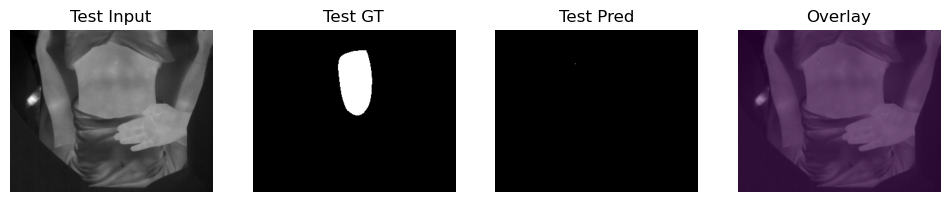

In [60]:
xb, yb, rb = next(iter(test_loader))

xb = xb.to(device)
yb = yb.to(device)
rb = rb.to(device)

model.eval()
with torch.no_grad():
    logits = model(xb)
    probs = torch.sigmoid(logits)

i = 0
th = 0.80

img = xb[i, 0].cpu().numpy()
gt  = yb[i, 0].cpu().numpy()
roi = rb[i, 0].cpu().numpy()

pred = (probs[i, 0].cpu().numpy() > th).astype(float)
pred_roi = pred * roi

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Test Input")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(gt, cmap="gray")
plt.title("Test GT")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(pred_roi, cmap="gray")
plt.title("Test Pred")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(img, cmap="gray")
plt.imshow(pred_roi, alpha=0.5)
plt.title("Overlay")
plt.axis("off")

plt.show()

# Step 38: Print Dice for each test image

In [61]:
th = 0.80

model.eval()

with torch.no_grad():
    for batch_idx, (xb, yb, rb) in enumerate(test_loader):
        xb = xb.to(device)
        yb = yb.to(device)
        rb = rb.to(device)

        logits = model(xb)
        probs = torch.sigmoid(logits)

        pred = (probs > th).float()
        pred_roi = pred * rb

        intersection = (pred_roi * yb).sum(dim=(1, 2, 3))
        union = pred_roi.sum(dim=(1, 2, 3)) + yb.sum(dim=(1, 2, 3))
        dice = (2 * intersection + 1e-6) / (union + 1e-6)

        for i in range(xb.size(0)):
            sample_idx = batch_idx * test_loader.batch_size + i
            print(
                f"{sample_idx:02d} | "
                f"{test_df.loc[sample_idx, 'image_name']} | "
                f"GT pixels: {yb[i].sum().item():.0f} | "
                f"Pred pixels: {pred_roi[i].sum().item():.0f} | "
                f"Dice: {dice[i].item():.4f}"
            )

00 | S11-A-1.bmp | GT pixels: 4483 | Pred pixels: 1 | Dice: 0.0000
01 | S11-A-2.bmp | GT pixels: 3526 | Pred pixels: 1826 | Dice: 0.2642
02 | S11-A-3.bmp | GT pixels: 4341 | Pred pixels: 2872 | Dice: 0.4783
03 | S11-B-1.bmp | GT pixels: 3542 | Pred pixels: 1906 | Dice: 0.4838
04 | S11-B-2.bmp | GT pixels: 501 | Pred pixels: 523 | Dice: 0.2715
05 | S11-B-3.bmp | GT pixels: 545 | Pred pixels: 186 | Dice: 0.3283
06 | S11-C-1.bmp | GT pixels: 1236 | Pred pixels: 393 | Dice: 0.3094
07 | S11-C-2.bmp | GT pixels: 1311 | Pred pixels: 132 | Dice: 0.0000
08 | S11-C-3.bmp | GT pixels: 1144 | Pred pixels: 136 | Dice: 0.0000
09 | S11-D-1.bmp | GT pixels: 527 | Pred pixels: 1237 | Dice: 0.0918
10 | S11-D-2.bmp | GT pixels: 1309 | Pred pixels: 1823 | Dice: 0.0441
11 | S11-D-3.bmp | GT pixels: 1369 | Pred pixels: 483 | Dice: 0.1458


# Step 39: Visualize all test predictions

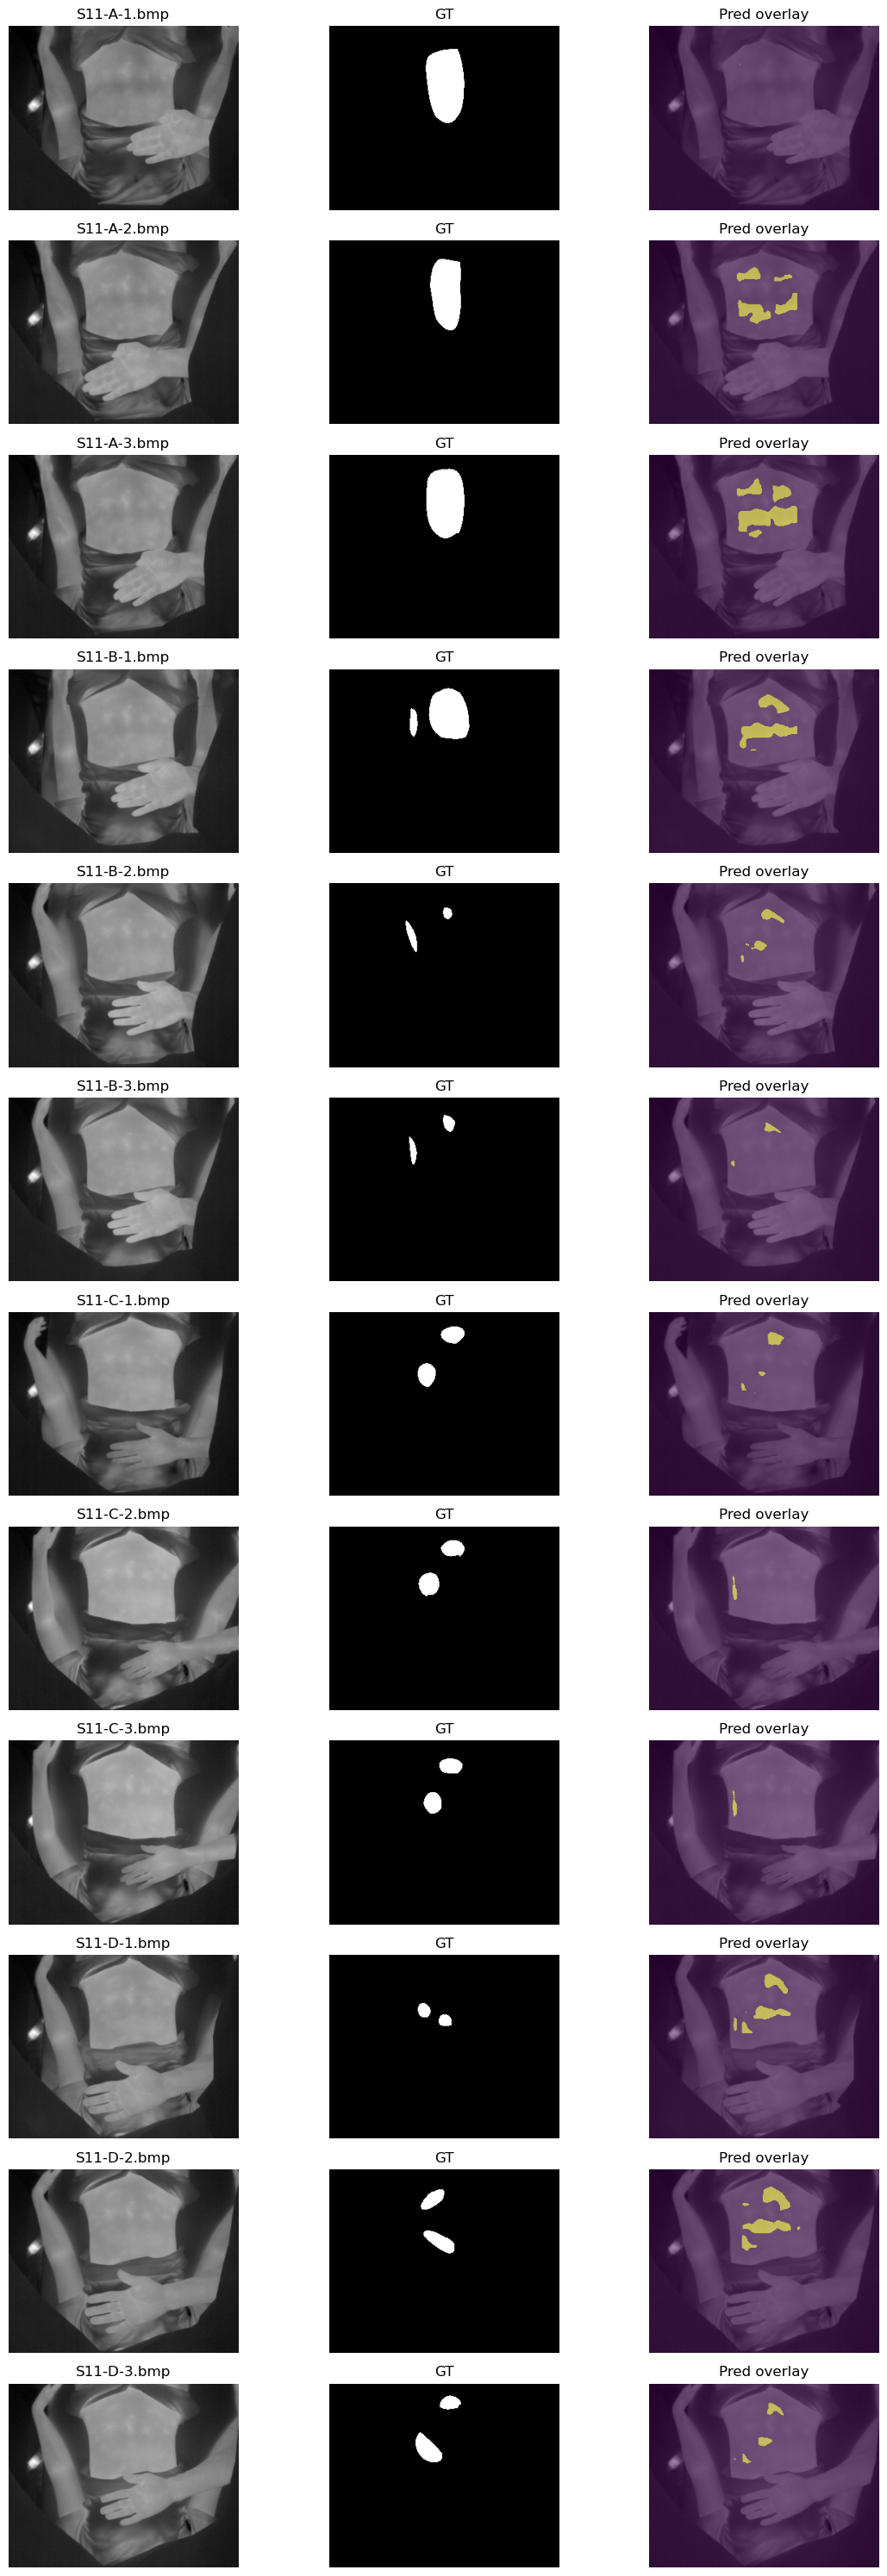

In [62]:
th = 0.80

model.eval()

all_imgs = []
all_gts = []
all_preds = []
all_names = []

with torch.no_grad():
    for xb, yb, rb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        rb = rb.to(device)

        logits = model(xb)
        probs = torch.sigmoid(logits)

        pred = (probs > th).float()
        pred_roi = pred * rb

        for i in range(xb.size(0)):
            all_imgs.append(xb[i, 0].cpu().numpy())
            all_gts.append(yb[i, 0].cpu().numpy())
            all_preds.append(pred_roi[i, 0].cpu().numpy())

start = 0
end = len(test_df)

plt.figure(figsize=(12, end * 2.5))

for i in range(start, end):
    img = all_imgs[i]
    gt = all_gts[i]
    pred = all_preds[i]

    plt.subplot(end, 3, i * 3 + 1)
    plt.imshow(img, cmap="gray")
    plt.title(test_df.loc[i, "image_name"])
    plt.axis("off")

    plt.subplot(end, 3, i * 3 + 2)
    plt.imshow(gt, cmap="gray")
    plt.title("GT")
    plt.axis("off")

    plt.subplot(end, 3, i * 3 + 3)
    plt.imshow(img, cmap="gray")
    plt.imshow(pred, alpha=0.5)
    plt.title("Pred overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()

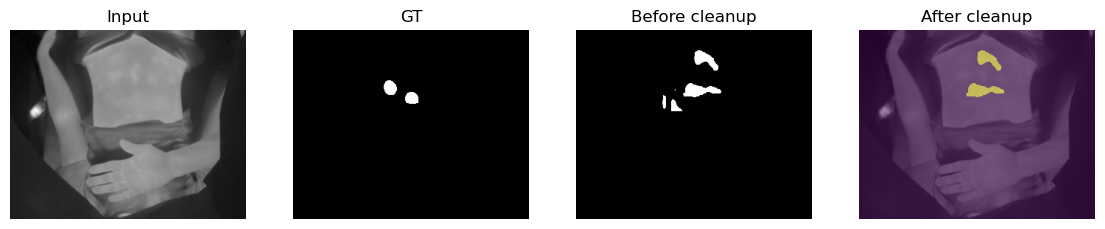

In [67]:
from scipy.ndimage import label

def keep_largest_component(mask):
    labeled, num = label(mask)

    if num == 0:
        return mask

    sizes = [(labeled == i).sum() for i in range(1, num + 1)]
    largest_id = np.argmax(sizes) + 1

    return (labeled == largest_id).astype(np.float32)


def keep_top_k_components(mask, k=2):
    labeled, num = label(mask)

    if num == 0:
        return mask

    sizes = [(labeled == i).sum() for i in range(1, num + 1)]
    top_ids = np.argsort(sizes)[-k:] + 1

    out = np.zeros_like(mask, dtype=np.float32)
    for comp_id in top_ids:
        out[labeled == comp_id] = 1.0

    return out

i = 1   # try sample 1 first
th = 0.80

img = xb[i, 0].detach().cpu().numpy()
gt  = yb[i, 0].detach().cpu().numpy()
roi = rb[i, 0].detach().cpu().numpy()

raw_pred = (probs[i, 0].detach().cpu().numpy() > th).astype(np.float32)
pred_roi = raw_pred * roi

pred_clean = keep_top_k_components(pred_roi, k=2)

plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(gt, cmap="gray")
plt.title("GT")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(pred_roi, cmap="gray")
plt.title("Before cleanup")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(img, cmap="gray")
plt.imshow(pred_clean, alpha=0.5)
plt.title("After cleanup")
plt.axis("off")

plt.show()

In [68]:
pred_clean = keep_top_k_components(pred_roi, k=2)

intersection = (pred_clean * gt).sum()
union = pred_clean.sum() + gt.sum()

dice_clean = (2 * intersection + 1e-6) / (union + 1e-6)

print("Before cleanup pixels:", pred_roi.sum())
print("After cleanup pixels:", pred_clean.sum())
print("GT pixels:", gt.sum())
print("Dice after top-2 cleanup:", dice_clean)

Before cleanup pixels: 1237.0
After cleanup pixels: 1019.0
GT pixels: 527.0
Dice after top-2 cleanup: 0.10219922438408846


In [69]:
th = 0.80

model.eval()
dice_list = []

with torch.no_grad():
    for batch_idx, (xb, yb, rb) in enumerate(test_loader):
        xb = xb.to(device)
        yb = yb.to(device)
        rb = rb.to(device)

        logits = model(xb)
        probs = torch.sigmoid(logits)

        for i in range(xb.size(0)):
            sample_idx = batch_idx * test_loader.batch_size + i

            gt = yb[i, 0].cpu().numpy()
            roi = rb[i, 0].cpu().numpy()

            pred = (probs[i, 0].cpu().numpy() > th).astype(np.float32)
            pred_roi = pred * roi
            pred_clean = keep_top_k_components(pred_roi, k=2)

            inter = (pred_clean * gt).sum()
            union = pred_clean.sum() + gt.sum()
            dice = (2 * inter + 1e-6) / (union + 1e-6)

            dice_list.append(dice)

            print(
                f"{sample_idx:02d} | "
                f"{test_df.loc[sample_idx, 'image_name']} | "
                f"GT: {gt.sum():.0f} | "
                f"Pred clean: {pred_clean.sum():.0f} | "
                f"Dice clean: {dice:.4f}"
            )

print("Mean test Dice after top-2 cleanup:", np.mean(dice_list))

00 | S11-A-1.bmp | GT: 4483 | Pred clean: 1 | Dice clean: 0.0000
01 | S11-A-2.bmp | GT: 3526 | Pred clean: 1305 | Dice clean: 0.1983
02 | S11-A-3.bmp | GT: 4341 | Pred clean: 2320 | Dice clean: 0.4126
03 | S11-B-1.bmp | GT: 3542 | Pred clean: 1891 | Dice clean: 0.4852
04 | S11-B-2.bmp | GT: 501 | Pred clean: 475 | Dice clean: 0.2848
05 | S11-B-3.bmp | GT: 545 | Pred clean: 186 | Dice clean: 0.3283
06 | S11-C-1.bmp | GT: 1236 | Pred clean: 348 | Dice clean: 0.3182
07 | S11-C-2.bmp | GT: 1311 | Pred clean: 132 | Dice clean: 0.0000
08 | S11-C-3.bmp | GT: 1144 | Pred clean: 136 | Dice clean: 0.0000
09 | S11-D-1.bmp | GT: 527 | Pred clean: 1019 | Dice clean: 0.1022
10 | S11-D-2.bmp | GT: 1309 | Pred clean: 1560 | Dice clean: 0.0160
11 | S11-D-3.bmp | GT: 1369 | Pred clean: 398 | Dice clean: 0.0962
Mean test Dice after top-2 cleanup: 0.18681772060872545


In [70]:
th = 0.80

rows = []

model.eval()

with torch.no_grad():
    for batch_idx, (xb, yb, rb) in enumerate(test_loader):
        xb = xb.to(device)
        yb = yb.to(device)
        rb = rb.to(device)

        logits = model(xb)
        probs = torch.sigmoid(logits)

        pred = (probs > th).float()
        pred_roi = pred * rb

        intersection = (pred_roi * yb).sum(dim=(1, 2, 3))
        union = pred_roi.sum(dim=(1, 2, 3)) + yb.sum(dim=(1, 2, 3))
        dice = (2 * intersection + 1e-6) / (union + 1e-6)

        for i in range(xb.size(0)):
            sample_idx = batch_idx * test_loader.batch_size + i

            rows.append({
                "image_name": test_df.loc[sample_idx, "image_name"],
                "subject": test_df.loc[sample_idx, "subject"],
                "doctor": test_df.loc[sample_idx, "doctor"],
                "try": test_df.loc[sample_idx, "try"],
                "gt_pixels": yb[i].sum().item(),
                "pred_pixels": pred_roi[i].sum().item(),
                "dice": dice[i].item()
            })

test_result_df = pd.DataFrame(rows)

print("Mean Dice:", test_result_df["dice"].mean())
test_result_df

Mean Dice: 0.20143592247603037


,image_name,subject,doctor,try,gt_pixels,pred_pixels,dice
0,S11-A-1.bmp,S11,A,1,4483.0,1.0,2.230152e-10
1,S11-A-2.bmp,S11,A,2,3526.0,1826.0,2.642003e-01
2,S11-A-3.bmp,S11,A,3,4341.0,2872.0,4.783031e-01
3,S11-B-1.bmp,S11,B,1,3542.0,1906.0,4.838473e-01
4,S11-B-2.bmp,S11,B,2,501.0,523.0,2.714844e-01
5,S11-B-3.bmp,S11,B,3,545.0,186.0,3.283174e-01
6,S11-C-1.bmp,S11,C,1,1236.0,393.0,3.093923e-01
7,S11-C-2.bmp,S11,C,2,1311.0,132.0,6.930007e-10
8,S11-C-3.bmp,S11,C,3,1144.0,136.0,7.812500e-10
9,S11-D-1.bmp,S11,D,1,527.0,1237.0,9.183674e-02


In [71]:
print("Mean Dice by doctor:")
print(test_result_df.groupby("doctor")["dice"].mean())

print("\nMean Dice by try:")
print(test_result_df.groupby("try")["dice"].mean())

Mean Dice by doctor:
doctor
A    0.247501
B    0.361216
C    0.103131
D    0.093895
Name: dice, dtype: float64

Mean Dice by try:
try
1    0.221269
2    0.144936
3    0.238102
Name: dice, dtype: float64


# Step 48: Create multi-class Dataset

In [73]:
class ColdRegionMultiClassDataset(Dataset):
    def __init__(self, df, img_size=(320, 256)):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        mask_path = self.df.loc[idx, "mask_path"]

        img = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        img = img.resize(self.img_size, resample=Image.BILINEAR)
        mask = mask.resize(self.img_size, resample=Image.NEAREST)

        img = np.array(img).astype(np.float32) / 255.0
        mask = np.array(mask).astype(np.uint8)

        # remap original label:
        # original 0/1 -> class 0 = background
        # original 2   -> class 1 = abdomen/body
        # original 3   -> class 2 = cold region
        new_mask = np.zeros_like(mask, dtype=np.int64)
        new_mask[mask == 2] = 1
        new_mask[mask == 3] = 2

        img = torch.tensor(img).unsqueeze(0)      # [1, H, W]
        new_mask = torch.tensor(new_mask).long()  # [H, W]

        return img, new_mask
    

train_ds_mc = ColdRegionMultiClassDataset(train_df)
val_ds_mc   = ColdRegionMultiClassDataset(val_df)
test_ds_mc  = ColdRegionMultiClassDataset(test_df)

x, y = train_ds_mc[0]

print("Image shape:", x.shape)
print("Mask shape:", y.shape)
print("Unique mask classes:", torch.unique(y))


from torch.utils.data import DataLoader

train_loader_mc = DataLoader(train_ds_mc, batch_size=4, shuffle=True)
val_loader_mc   = DataLoader(val_ds_mc, batch_size=4, shuffle=False)
test_loader_mc  = DataLoader(test_ds_mc, batch_size=4, shuffle=False)

xb, yb = next(iter(train_loader_mc))

print("Image batch:", xb.shape)
print("Mask batch:", yb.shape)
print("Unique classes in batch:", torch.unique(yb))

Image shape: torch.Size([1, 256, 320])
Mask shape: torch.Size([256, 320])
Unique mask classes: tensor([0, 1, 2])
Image batch: torch.Size([4, 1, 256, 320])
Mask batch: torch.Size([4, 256, 320])
Unique classes in batch: tensor([0, 1, 2])


In [74]:
class SmallUNetMultiClass(SmallUNet):
    def __init__(self, num_classes=3):
        super().__init__()
        self.out = nn.Conv2d(16, num_classes, 1)

In [75]:
model_mc = SmallUNetMultiClass(num_classes=3).to(device)

xb, yb = next(iter(train_loader_mc))
xb = xb.to(device)

out = model_mc(xb)

print("Input image:", xb.shape)
print("Model output:", out.shape)
print("Ground truth mask:", yb.shape)

Input image: torch.Size([4, 1, 256, 320])
Model output: torch.Size([4, 3, 256, 320])
Ground truth mask: torch.Size([4, 256, 320])


In [76]:
import torch.nn.functional as F

class_weights = torch.tensor([0.2, 1.0, 20.0], device=device)

def multiclass_loss(logits, targets):
    return F.cross_entropy(logits, targets, weight=class_weights)

def cold_dice_from_multiclass(logits, targets, eps=1e-6):
    pred_class = torch.argmax(logits, dim=1)

    pred_cold = (pred_class == 2).float()
    true_cold = (targets == 2).float()

    intersection = (pred_cold * true_cold).sum(dim=(1, 2))
    union = pred_cold.sum(dim=(1, 2)) + true_cold.sum(dim=(1, 2))

    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean()

In [77]:
model_mc = SmallUNetMultiClass(num_classes=3).to(device)
optimizer_mc = torch.optim.Adam(model_mc.parameters(), lr=1e-3)

best_val_dice = -1
best_path_mc = "best_multiclass_unet.pt"

num_epochs = 50

for epoch in range(1, num_epochs + 1):
    model_mc.train()
    train_loss = 0
    train_dice = 0

    for xb, yb in train_loader_mc:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer_mc.zero_grad()

        logits = model_mc(xb)
        loss = multiclass_loss(logits, yb)

        loss.backward()
        optimizer_mc.step()

        dice = cold_dice_from_multiclass(logits.detach(), yb)

        train_loss += loss.item()
        train_dice += dice.item()

    train_loss /= len(train_loader_mc)
    train_dice /= len(train_loader_mc)

    model_mc.eval()
    val_loss = 0
    val_dice = 0

    with torch.no_grad():
        for xb, yb in val_loader_mc:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model_mc(xb)
            loss = multiclass_loss(logits, yb)
            dice = cold_dice_from_multiclass(logits, yb)

            val_loss += loss.item()
            val_dice += dice.item()

    val_loss /= len(val_loader_mc)
    val_dice /= len(val_loader_mc)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model_mc.state_dict(), best_path_mc)
        save_msg = "saved"
    else:
        save_msg = ""

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | Train Cold Dice: {train_dice:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Cold Dice: {val_dice:.4f} "
        f"{save_msg}"
    )

print("Best Val Cold Dice:", best_val_dice)
print("Saved model:", best_path_mc)

Epoch 01 | Train Loss: 1.1138 | Train Cold Dice: 0.0179 | Val Loss: 1.0611 | Val Cold Dice: 0.0000 saved
Epoch 02 | Train Loss: 1.0457 | Train Cold Dice: 0.0179 | Val Loss: 1.0252 | Val Cold Dice: 0.0000 
Epoch 03 | Train Loss: 0.8950 | Train Cold Dice: 0.0200 | Val Loss: 0.9249 | Val Cold Dice: 0.0251 saved
Epoch 04 | Train Loss: 0.8233 | Train Cold Dice: 0.0500 | Val Loss: 0.7438 | Val Cold Dice: 0.0063 
Epoch 05 | Train Loss: 0.6959 | Train Cold Dice: 0.0404 | Val Loss: 0.5582 | Val Cold Dice: 0.0270 saved
Epoch 06 | Train Loss: 0.6398 | Train Cold Dice: 0.0523 | Val Loss: 0.5005 | Val Cold Dice: 0.0517 saved
Epoch 07 | Train Loss: 0.7134 | Train Cold Dice: 0.0334 | Val Loss: 0.7193 | Val Cold Dice: 0.0205 
Epoch 08 | Train Loss: 0.7238 | Train Cold Dice: 0.0405 | Val Loss: 0.5547 | Val Cold Dice: 0.0032 
Epoch 09 | Train Loss: 0.6586 | Train Cold Dice: 0.0387 | Val Loss: 0.5414 | Val Cold Dice: 0.0376 
Epoch 10 | Train Loss: 0.6970 | Train Cold Dice: 0.0478 | Val Loss: 0.5604 | Val

In [78]:
model_mc = SmallUNetMultiClass(num_classes=3).to(device)
model_mc.load_state_dict(torch.load("best_multiclass_unet.pt", map_location=device))
model_mc.eval()

rows_mc = []

with torch.no_grad():
    for batch_idx, (xb, yb) in enumerate(test_loader_mc):
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model_mc(xb)
        pred_class = torch.argmax(logits, dim=1)

        pred_cold = (pred_class == 2).float()
        true_cold = (yb == 2).float()

        intersection = (pred_cold * true_cold).sum(dim=(1, 2))
        union = pred_cold.sum(dim=(1, 2)) + true_cold.sum(dim=(1, 2))
        dice = (2 * intersection + 1e-6) / (union + 1e-6)

        for i in range(xb.size(0)):
            sample_idx = batch_idx * test_loader_mc.batch_size + i

            rows_mc.append({
                "image_name": test_df.loc[sample_idx, "image_name"],
                "subject": test_df.loc[sample_idx, "subject"],
                "doctor": test_df.loc[sample_idx, "doctor"],
                "try": test_df.loc[sample_idx, "try"],
                "gt_pixels": true_cold[i].sum().item(),
                "pred_pixels": pred_cold[i].sum().item(),
                "dice": dice[i].item()
            })

test_result_mc_df = pd.DataFrame(rows_mc)

print("Multi-class Test Mean Dice:", test_result_mc_df["dice"].mean())
test_result_mc_df

Multi-class Test Mean Dice: 0.267348600551486


/tmp/ipykernel_2878726/314565000.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_mc.load_state_dict(torch.load("best_multiclass_unet.pt", map_location=device))


,image_name,subject,doctor,try,gt_pixels,pred_pixels,dice
0,S11-A-1.bmp,S11,A,1,4483.0,4480.0,0.231396
1,S11-A-2.bmp,S11,A,2,3526.0,8850.0,0.474628
2,S11-A-3.bmp,S11,A,3,4341.0,9330.0,0.551094
3,S11-B-1.bmp,S11,B,1,3542.0,7190.0,0.560007
4,S11-B-2.bmp,S11,B,2,501.0,6263.0,0.091070
5,S11-B-3.bmp,S11,B,3,545.0,5702.0,0.146951
6,S11-C-1.bmp,S11,C,1,1236.0,6556.0,0.315965
7,S11-C-2.bmp,S11,C,2,1311.0,2229.0,0.096610
8,S11-C-3.bmp,S11,C,3,1144.0,2048.0,0.135338
9,S11-D-1.bmp,S11,D,1,527.0,8507.0,0.116449


In [79]:
print("Binary Test Mean Dice:", test_result_df["dice"].mean())
print("Multi-class Test Mean Dice:", test_result_mc_df["dice"].mean())

print("\nMulti-class Dice by doctor:")
print(test_result_mc_df.groupby("doctor")["dice"].mean())

print("\nMulti-class Dice by try:")
print(test_result_mc_df.groupby("try")["dice"].mean())

Binary Test Mean Dice: 0.20143592247603037
Multi-class Test Mean Dice: 0.267348600551486

Multi-class Dice by doctor:
doctor
A    0.419039
B    0.266009
C    0.182638
D    0.201708
Name: dice, dtype: float64

Multi-class Dice by try:
try
1    0.305954
2    0.217628
3    0.278464
Name: dice, dtype: float64


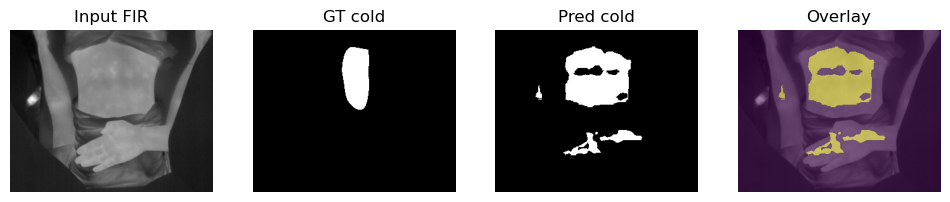

In [80]:
xb, yb = next(iter(test_loader_mc))

xb = xb.to(device)
yb = yb.to(device)

model_mc.eval()
with torch.no_grad():
    logits = model_mc(xb)
    pred_class = torch.argmax(logits, dim=1)

i = 1

img = xb[i, 0].cpu().numpy()
gt_cold = (yb[i].cpu().numpy() == 2).astype(float)
pred_cold = (pred_class[i].cpu().numpy() == 2).astype(float)

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Input FIR")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(gt_cold, cmap="gray")
plt.title("GT cold")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(pred_cold, cmap="gray")
plt.title("Pred cold")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(img, cmap="gray")
plt.imshow(pred_cold, alpha=0.5)
plt.title("Overlay")
plt.axis("off")

plt.show()

In [81]:
xb, yb = next(iter(test_loader_mc))

xb = xb.to(device)
yb = yb.to(device)

model_mc.eval()
with torch.no_grad():
    logits = model_mc(xb)
    probs = torch.softmax(logits, dim=1)

cold_prob = probs[:, 2]   # probability of class 2 = cold

for th in [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]:
    pred_cold = (cold_prob > th).float()
    true_cold = (yb == 2).float()

    intersection = (pred_cold * true_cold).sum(dim=(1, 2))
    union = pred_cold.sum(dim=(1, 2)) + true_cold.sum(dim=(1, 2))
    dice = (2 * intersection + 1e-6) / (union + 1e-6)

    print(
        f"Threshold {th:.2f} | "
        f"Pred pixels: {pred_cold.sum().item():.0f} | "
        f"Dice: {dice.mean().item():.4f}"
    )

Threshold 0.50 | Pred pixels: 27918 | Dice: 0.4574
Threshold 0.60 | Pred pixels: 22811 | Dice: 0.4685
Threshold 0.70 | Pred pixels: 17004 | Dice: 0.4501
Threshold 0.80 | Pred pixels: 8818 | Dice: 0.3349
Threshold 0.90 | Pred pixels: 0 | Dice: 0.0000
Threshold 0.95 | Pred pixels: 0 | Dice: 0.0000


In [82]:
th = 0.60

model_mc.eval()
rows_mc_th = []

with torch.no_grad():
    for batch_idx, (xb, yb) in enumerate(test_loader_mc):
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model_mc(xb)
        probs = torch.softmax(logits, dim=1)

        cold_prob = probs[:, 2]
        pred_cold = (cold_prob > th).float()
        true_cold = (yb == 2).float()

        intersection = (pred_cold * true_cold).sum(dim=(1, 2))
        union = pred_cold.sum(dim=(1, 2)) + true_cold.sum(dim=(1, 2))
        dice = (2 * intersection + 1e-6) / (union + 1e-6)

        for i in range(xb.size(0)):
            sample_idx = batch_idx * test_loader_mc.batch_size + i

            rows_mc_th.append({
                "image_name": test_df.loc[sample_idx, "image_name"],
                "doctor": test_df.loc[sample_idx, "doctor"],
                "try": test_df.loc[sample_idx, "try"],
                "gt_pixels": true_cold[i].sum().item(),
                "pred_pixels": pred_cold[i].sum().item(),
                "dice": dice[i].item()
            })

test_result_mc_th_df = pd.DataFrame(rows_mc_th)

print("Multi-class Test Mean Dice @0.60:", test_result_mc_th_df["dice"].mean())
test_result_mc_th_df

Multi-class Test Mean Dice @0.60: 0.27025580972285207


,image_name,doctor,try,gt_pixels,pred_pixels,dice
0,S11-A-1.bmp,A,1,4483.0,3301.0,2.096608e-01
1,S11-A-2.bmp,A,2,3526.0,6802.0,5.112316e-01
2,S11-A-3.bmp,A,3,4341.0,7422.0,5.789340e-01
3,S11-B-1.bmp,B,1,3542.0,5286.0,5.743090e-01
4,S11-B-2.bmp,B,2,501.0,4199.0,1.000000e-01
5,S11-B-3.bmp,B,3,545.0,3222.0,1.826387e-01
6,S11-C-1.bmp,C,1,1236.0,4032.0,4.134396e-01
7,S11-C-2.bmp,C,2,1311.0,1126.0,4.103406e-10
8,S11-C-3.bmp,C,3,1144.0,1002.0,4.659832e-10
9,S11-D-1.bmp,D,1,527.0,5607.0,1.111836e-01
